**Importing the Libraries**

In [2]:
import numpy as np
np.random.seed(42)

In [11]:
import matplotlib.pyplot as plt 
import matplotlib.animation as animation 
from matplotlib.animation import PillowWriter

------------------------------

**Single variable**

In [5]:
def f(x):              
    return x - x**3                   

In [6]:
def fdash(x):
    return 1 - 3*(x**2)        

<br>

In [8]:
point = -1
learning_rate = 0.01

momentum = 0.9
update = 0

for i in range(1000):
    update = - learning_rate * fdash(point) + momentum * update
    update_ = - learning_rate * fdash(point) + momentum * update
    point += update_
    
point

-0.5773502691896257

------------------------------

**Animation for SGD with Nesterov acceleration**

In [12]:
point_sgd_nesterov = [-1]

In [13]:
point = -1
learning_rate = 0.01

momentum = 0.9
update = 0

for i in range(1000):
    update = - learning_rate * fdash(point) + momentum * update
    update_ = - learning_rate * fdash(point) + momentum * update
    point += update_
    
    point_sgd_nesterov.append(point)
    
point

-0.5773502691896257

<br>

In [15]:
plt.rcParams.update({'font.size': 22})

Text(0.5, 1.0, 'SGD with Nesterov acceleration, learning_rate = 0.01')

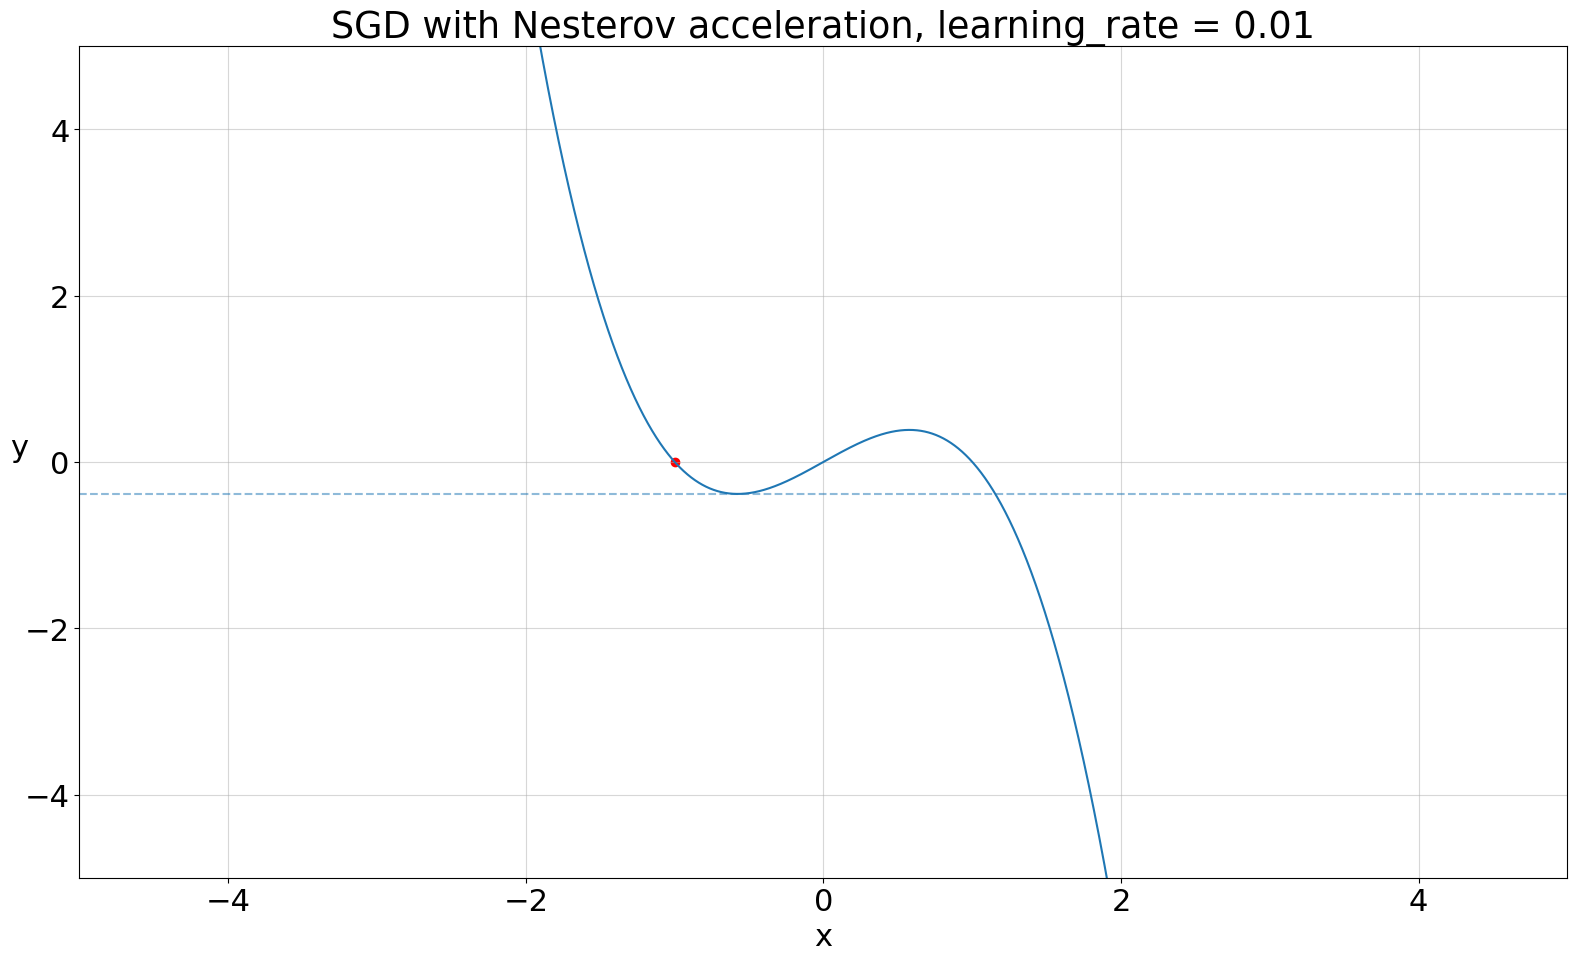

In [16]:
fig = plt.figure(dpi = 100)

fig.set_figheight(10.80)
fig.set_figwidth(19.20)

x_ = np.linspace(-5, 5, 10000)
y_ = f(x_)

ax = plt.axes()
ax.plot(x_, y_)
ax.grid(alpha = 0.5)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel('x')
ax.set_ylabel('y', rotation = 0)
ax.scatter(-1, f(-1), color = 'red')
ax.hlines(f(-0.5773502691896256), -5, 5, linestyles = 'dashed', alpha = 0.5)

ax.set_title('SGD with Nesterov acceleration, learning_rate = 0.01')

In [17]:
def animate(i):
    ax.clear()
    ax.plot(x_, y_)
    ax.grid(alpha = 0.5)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('y', rotation = 0)
    ax.hlines(f(-0.5773502691896256), -5, 5, linestyles = 'dashed', alpha = 0.5)
    ax.set_title('SGD with Nesterov acceleration, learning_rate = 0.01')
    
    ax.scatter(point_sgd_nesterov[i], f(point_sgd_nesterov[i]), color = 'red')

In [18]:
anim = animation.FuncAnimation(fig, animate, frames = 200, interval = 20)

anim.save('2.3 SGD with Nesterov acceleration.gif')

MovieWriter ffmpeg unavailable; using Pillow instead.


-------------------------------

**Two variables**

In [21]:
def f(x, y):                
    return 2*(x**2) + 2*x*y + 2*(y**2) - 6*x  

In [22]:
def fdash_x(x, y):
    return 4*x + 2*y - 6            

In [23]:
def fdash_y(x, y):
    return 2*x + 4*y            

In [24]:
def gradient(point):
    return np.array([[     fdash_x(point[0][0], point[1][0])     ],
                     [     fdash_y(point[0][0], point[1][0])     ]], dtype = np.float64)

<br>

In [26]:
point = np.array([[   1   ],
                  [   0   ]], dtype = np.float64)

learning_rate = 0.01

momentum = 0.9
update = np.array([[   0   ],
                   [   0   ]], dtype = np.float64)

for i in range(1000):
    update = - learning_rate * gradient(point) + momentum * update
    update_ = - learning_rate * gradient(point) + momentum * update
    point += update_
    
point

array([[ 2.],
       [-1.]])